# Cached data exploration

Walks through the **numpy `.npz` cache** living under
`data/cached/{pd,lgd}/<dataset_id>/chunk_NNN.npz` plus each
dataset's `meta.json` sidecar. The story this notebook tells is
*are the chunks healthy and ready for the multi-table fine-tuning
loop?*

**Designed for the 3 000-dataset corpus.** Every plot is either a
corpus-level histogram or a paginated per-dataset view bounded by
`max_show`. Per-cell or per-feature views aren't included — they
don't visualise meaningfully across thousands of cached chunks.

## What's in a cached chunk?

Every `chunk_NNN.npz` contains:

* `X_context (n_ctx, n_features)` — the labelled context split
  fed to TabPFN at `.fit()` time.
* `y_context (n_ctx,)` — int64 for PD, float32 for LGD.
* `X_query (n_qry, n_features)` — the held-out split that becomes
  the prediction target during pretraining.
* `y_query (n_qry,)` — same dtype as `y_context`.
* `categorical_idx (n_cat,)` — int32 indices of categorical columns
  in `X_*`. Used by TabPFN's encoder steps.

## Sections

1. Cached corpus summary
2. Chunk count distribution (per track)
3. Mean chunk size distribution
4. Encoder sanity — unknown-sentinel rate per dataset
5. Within-dataset target consistency across chunks
6. Anomaly scan — datasets with suspicious cache state

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
REPO = Path(os.getcwd()).resolve()
while not (REPO / 'src' / 'data' / 'exploration.py').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import pandas as pd, numpy as np
from src.data.exploration import (
    cached_corpus_summary, list_cached_chunks, load_cached_chunk,
    load_cached_meta,
    plot_chunk_count_distribution, plot_chunk_size_distribution,
    plot_unknown_sentinel_rate, plot_chunk_target_consistency,
    find_anomalous_chunks,
)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

from src.utils.figures import open_figure_sink
sink = open_figure_sink('0.2_cached_data_exploration')


## 1. Cached corpus summary

One row per cached dataset. Columns:

* `n_chunks` — number of `chunk_*.npz` files on disk.
* `mean_chunk_rows` — average chunk size (context + query rows).
* `total_size_mb` — sum of `.npz` file sizes per dataset.
* `ctx_query_ratio` — `len(X_context) / total` averaged across
  chunks. Should be very close to `cfg.dataset.context_fraction`
  (default 0.60). Deviations indicate stale cache vs. updated cfg.
* `unknown_sentinel_rate` — fraction of categorical cells in the
  *query* split that received the encoder's `unknown_value` (`-1`
  by default) — i.e. categories that appeared in query but never
  in context. Validates that the encoder was correctly fit on
  context only (the bug we fixed in turn 17).
* `nan_rate_in_X` — fraction of NaN cells in `X_context ∪ X_query`.

In [2]:
cached = cached_corpus_summary()
cached.sort_values(['track', 'n_chunks'], ascending=[True, False])

,track,dataset_id,n_chunks,mean_chunk_rows,total_size_mb,ctx_query_ratio,unknown_sentinel_rate,nan_rate_in_X,task_type
17,lgd,0001.heloc,1,57932.00,0.77,0.6000,0.0000,0.0382,regression
18,lgd,0002.loss2,1,4637.00,0.37,0.6000,0.0009,0.0519,regression
19,lgd,0003.axa,1,2545.00,0.02,0.6000,0.0000,0.0000,regression
20,lgd,0004.base_model,1,762.00,0.11,0.5997,0.0067,0.1760,regression
21,lgd,0005.base_modelisation,1,594.00,0.14,0.5993,0.0159,0.0025,regression
22,lgd,0006.lgd_freddie,1,16002.00,0.37,0.6000,0.0002,0.0117,regression
23,lgd,0007.lgd_lendingclub,1,5627.00,0.14,0.6000,0.0078,0.0033,regression
24,lgd,0008.SBA_loans_case,1,686.00,0.02,0.6006,0.0009,0.0033,regression
15,pd,0016.bondora_peer2peer,8,91272.00,6.61,0.6000,0.0000,0.1169,classification
5,pd,0006.hackerearth,6,88738.00,23.54,0.6000,0.0000,0.0671,classification


---

## 2. Chunk count distribution

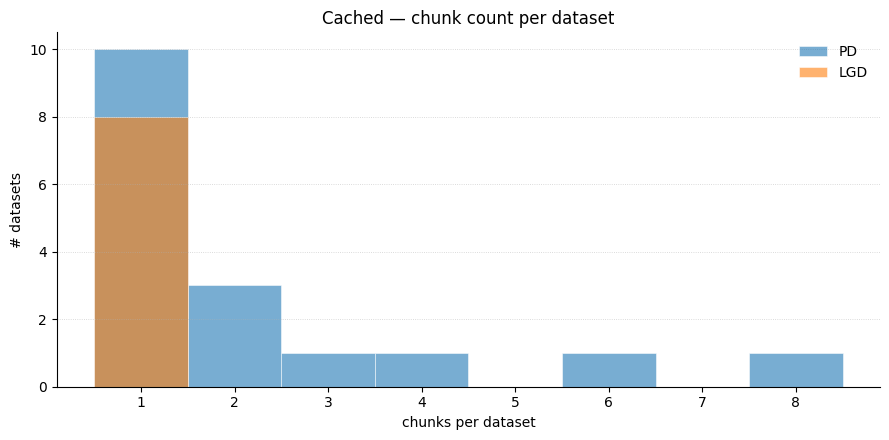

In [3]:
sink.save(plot_chunk_count_distribution(), '01_chunk_count_distribution')

## 3. Mean chunk size

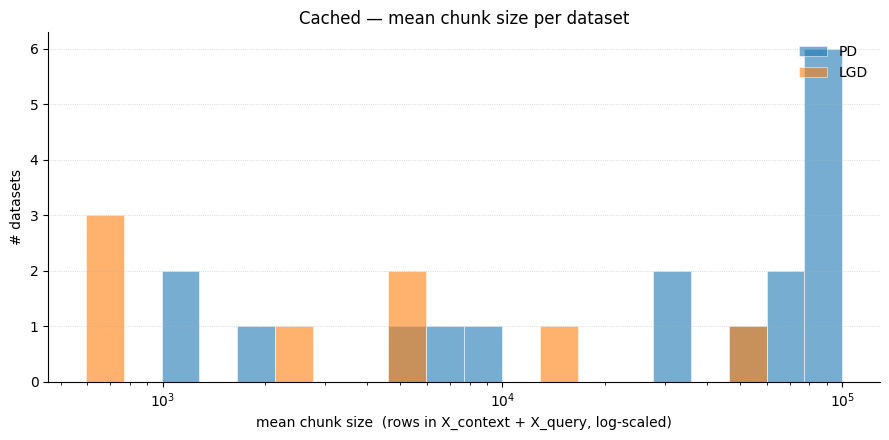

In [4]:
sink.save(plot_chunk_size_distribution(), '02_chunk_size_distribution')

---

## 4. Encoder sanity — unknown-sentinel rate

After turn-17 fix, the categorical encoder is fit on the context
split only. Categories appearing in the query but not in context
get encoded as `-1`. The fraction of `-1`s in the query categorical
cells is a direct measurement of how often this happens — and a
regression test that the fix didn't get reverted.

Expected: low rates (close to 0) for datasets with low-cardinality
categoricals; non-zero rates for high-cardinality categoricals
(e.g. `manufacturer_id` has ~11 distinct values, so a small
fraction will be context-unseen).

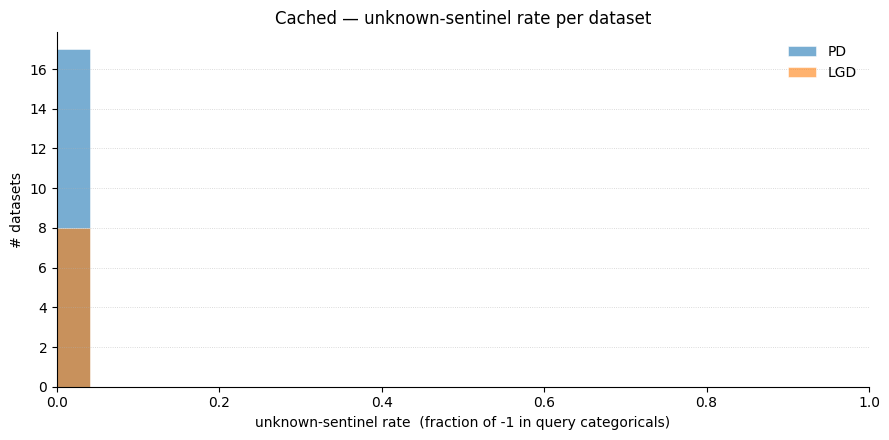

In [5]:
sink.save(plot_unknown_sentinel_rate(), '03_unknown_sentinel_rate')

---

## 5. Within-dataset target consistency across chunks

For each dataset that has > 1 chunk, plot the per-chunk target
statistic (class-1 fraction for PD, mean target for LGD).

* PD: stratified chunking should make these almost flat across
  chunks. Significant variance ⇒ stratification didn't take.
* LGD: random chunking — small variance is expected and the bars
  should hover around the dataset-level mean.

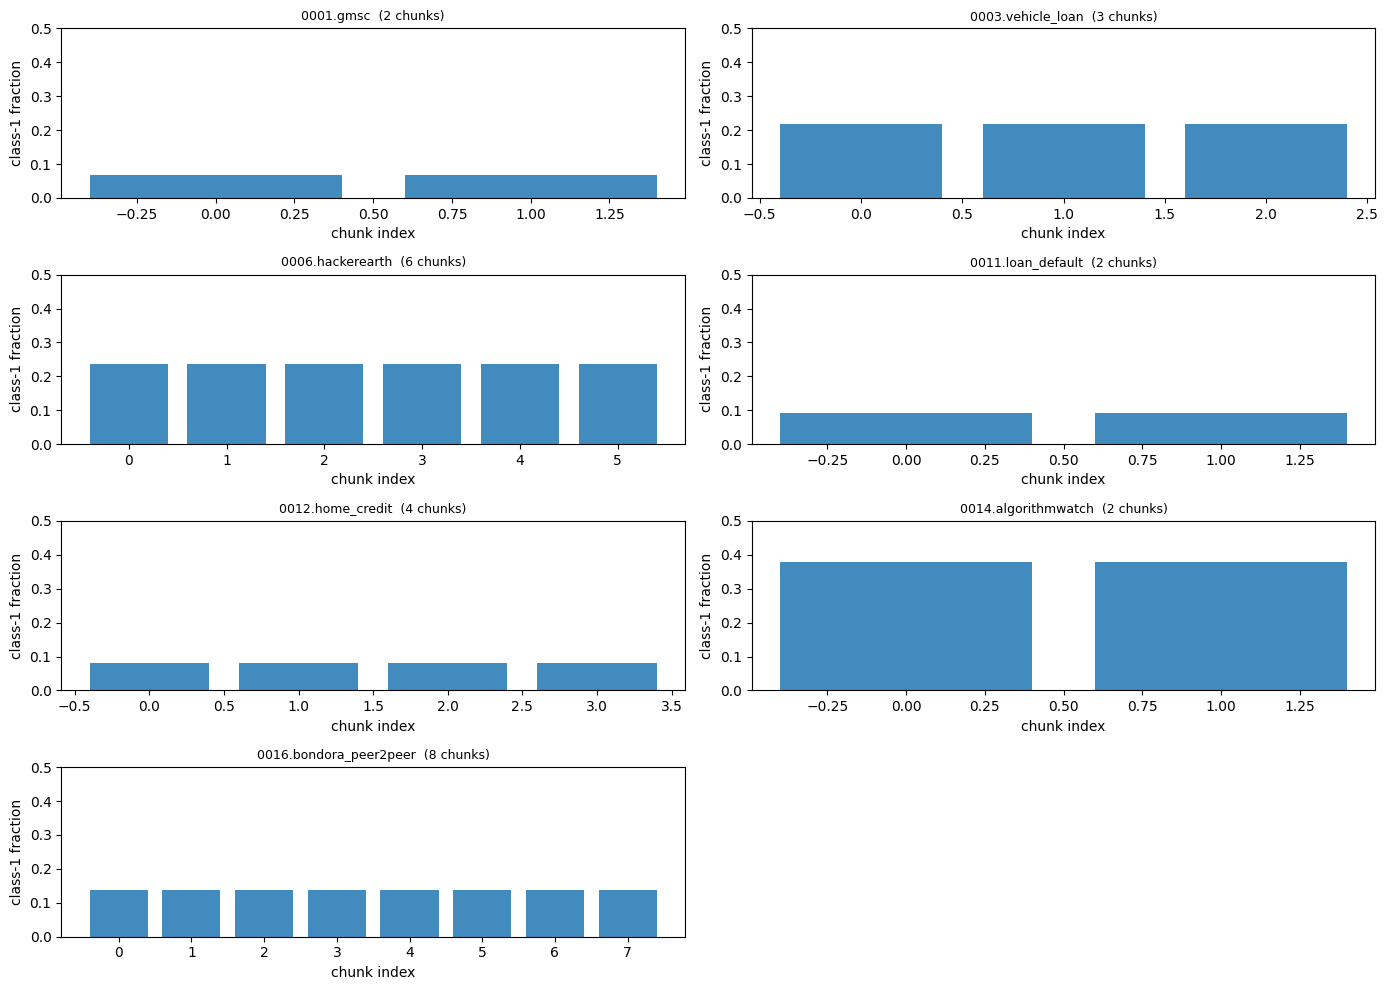

In [6]:
sink.save(plot_chunk_target_consistency('pd', max_show=12), '04_chunk_target_consistency')

In [7]:
sink.save(plot_chunk_target_consistency('lgd', max_show=12), '05_chunk_target_consistency')

---

## 6. Anomaly scan — cached

Flags cached datasets with:

* `no_chunks` — empty cache.
* `ctx_query_off` — average context fraction differs from
  `cfg.dataset.context_fraction` by > 0.10. Stale cache vs. config.
* `high_unknown_sentinel` — > 30% of query categorical cells were
  context-unseen. Worth a manual look.
* `too_many_nans` — > 50% of X-cells are NaN. Sanitisation didn't
  drop enough.

In [8]:
anomalies = find_anomalous_chunks()
if len(anomalies) == 0:
    print('No anomalies flagged across the cached corpus.')
else:
    display(anomalies)

No anomalies flagged across the cached corpus.


---

## 7. Drill-down: inspect one chunk by hand

Useful for spot-debugging. Pick a `(track, dataset_id)`, list the
chunk files, and load one to look at the array shapes and dtypes.

In [9]:
track, dataset_id = 'pd', '0001.gmsc'
chunks = list_cached_chunks(track, dataset_id)
print(f'{track}/{dataset_id} has {len(chunks)} chunks')
meta = load_cached_meta(track, dataset_id)
print('meta:', meta)
if chunks:
    d = load_cached_chunk(chunks[0])
    print('chunk_000 shapes:')
    for k in d.files:
        print(f'  {k}: shape={d[k].shape}  dtype={d[k].dtype}')

pd/0001.gmsc has 2 chunks
meta: {'dataset_id': '0001.gmsc', 'track': 'pd', 'task_type': 'classification', 'n_chunks': 2, 'n_rows_total': 150000, 'n_features': 10, 'categorical_idx': [], 'categorical_columns': [], 'context_fraction': 0.6, 'max_rows_per_chunk': 100000, 'seed': 42, 'chunk_seed': 62382, 'cache_schema_version': 2, 'cache_fingerprint': 'e3fab01ffcb5fe765a01a3de0ec7f4a82219ef8ff03839a95d354713a2e65ef1', 'manifest_row_hash': 'dcccde8dde72c36971b233f0ac11b1d94a658399bc2c8a2b7d5d4a5538fd98fe', 'processed_csv_sha256': '5630a0287edab71010d682cde826df1aaea7375f2762d964e6987422e8db7f49', 'dataset_config_hash': 'c713243462dd99468f4104ff0c261cb3307373128b8911317b8262fee221f175', 'encoded_missing_value': 'nan'}
chunk_000 shapes:
  X_context: shape=(45000, 10)  dtype=float32
  y_context: shape=(45000,)  dtype=int64
  X_query: shape=(30000, 10)  dtype=float32
  y_query: shape=(30000,)  dtype=int64
  categorical_idx: shape=(0,)  dtype=int32
